In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, lil_matrix
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import pyreadr 
from pathlib import Path
import os

os.chdir(Path.cwd().parent)


S = 1601, T = 2704
Total pooled transitions: 540600
AUC IID        = 0.9844
AUC BYM        = 0.9844
AUC BYM+factor = 0.9846


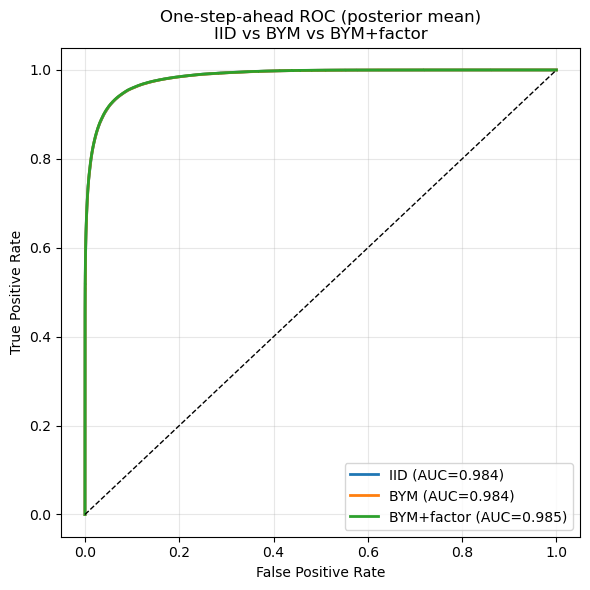

In [2]:
# ================================================================
# FAST PPC: One-step-ahead ROC
# IID vs BYM vs BYM+factor
# posterior mean, pooled over time
# ================================================================

import numpy as np
import pyreadr
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pandas as pd

# ================================================================
# CONFIG
# ================================================================
BASE_DIR = Path(r"D:\77\Research\temp\snow")
period = 52
np.random.seed(0)

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

N_SUB = 200   # number of spatial locations

# ================================================================
# LOAD DATA (NON-ISOLATED)
# ================================================================
snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)

y_full = snow.iloc[:, 2:].to_numpy()
coords_full = snow.iloc[:, :2].to_numpy()

y = np.delete(y_full, no_nbs, axis=0)
coords = np.delete(coords_full, no_nbs, axis=0)

S, T = y.shape
print(f"S = {S}, T = {T}")

# ------------------------------------------------
# subsample locations
# ------------------------------------------------
sub_idx = np.random.choice(S, size=N_SUB, replace=False)
y_sub = y[sub_idx, :]

# ================================================================
# BUILD ONE-STEP-AHEAD DATA (POOL OVER TIME)
# ================================================================
Y_true, Y_prev, time_idx, loc_idx = [], [], [], []

for ii, s in enumerate(sub_idx):
    for t in range(1, T):
        Y_prev.append(y[s, t-1])
        Y_true.append(y[s, t])
        time_idx.append(t)
        loc_idx.append(s)

Y_true = np.asarray(Y_true)
Y_prev = np.asarray(Y_prev)
time_idx = np.asarray(time_idx)
loc_idx  = np.asarray(loc_idx)

N = len(Y_true)
print("Total pooled transitions:", N)

# ================================================================
# LOAD POSTERIOR MEAN PARAMETERS
# ================================================================
iid01  = np.load(BASE_DIR / "ind01_noIso.npz")["all_theta"].mean(axis=1)
iid10  = np.load(BASE_DIR / "ind10_noIso.npz")["all_theta"].mean(axis=1)

bym01  = np.load(BASE_DIR / "bym01_noIso_final.npz")["all_theta"].mean(axis=1)
bym10  = np.load(BASE_DIR / "bym10_noIso_final.npz")["all_theta"].mean(axis=1)

bymf01 = np.load(BASE_DIR / "bym_factor_01_noiso.npz")["all_theta"].mean(axis=1)
bymf10 = np.load(BASE_DIR / "bym_factor_10_noiso.npz")["all_theta"].mean(axis=1)

# ================================================================
# GLOBAL TIME VARIABLES (MATCH DIC & MCMC)
# ================================================================
t_raw = np.arange(1, T + 1)
t_trend_full = (t_raw - t_raw.mean()) / t_raw.std(ddof=0)

cov_bym = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw/period), np.cos(2*np.pi*t_raw/period),
    np.sin(2*np.pi*t_raw/period), np.sin(2*np.pi*t_raw/period),
    t_trend_full, t_trend_full
])

cov_iid = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw/period),
    np.sin(2*np.pi*t_raw/period),
    t_trend_full
])

# ================================================================
# FACTOR COMPONENTS (GLOBAL SCALE)
# ================================================================
# latitude
lat_raw = coords[:, 1]
lats = (lat_raw - lat_raw.mean()) / lat_raw.std(ddof=1)

# elevation
curr_elev = pd.read_csv("curr_elev.csv").iloc[:, 3].to_numpy()
elev = (curr_elev - curr_elev.mean()) / curr_elev.std(ddof=1)

# temperature
snow_temp = pyreadr.read_r(BASE_DIR / "snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)
temp_full = snow_temp.iloc[:, 2:].to_numpy()
temp = np.delete(temp_full, no_nbs, axis=0)
temp_scaled = (temp - temp.mean()) / temp.std(ddof=0)

# ================================================================
# ONE-STEP-AHEAD PREDICTIVE PROBABILITIES
# ================================================================
p_iid  = np.zeros(N)
p_bym  = np.zeros(N)
p_bymf = np.zeros(N)

for n in range(N):

    s = loc_idx[n]
    t = time_idx[n]

    # ================= IID =================
    eta01 = 0.0
    eta10 = 0.0
    for k in range(4):
        eta01 += cov_iid[t, k] * iid01[k*S + s]
        eta10 += cov_iid[t, k] * iid10[k*S + s]

    p01 = 1 / (1 + np.exp(-eta01))
    p10 = 1 / (1 + np.exp(-eta10))
    p_iid[n] = p01 if Y_prev[n] == 0 else (1 - p10)

    # ================= BYM =================
    eta01 = 0.0
    eta10 = 0.0
    for k in range(8):
        eta01 += cov_bym[t, k] * bym01[k*S + s]
        eta10 += cov_bym[t, k] * bym10[k*S + s]

    p01 = 1 / (1 + np.exp(-eta01))
    p10 = 1 / (1 + np.exp(-eta10))
    p_bym[n] = p01 if Y_prev[n] == 0 else (1 - p10)

    # ================= BYM + factor =================
    eta01 = 0.0
    eta10 = 0.0
    for k in range(8):
        eta01 += cov_bym[t, k] * bymf01[k*S + s]
        eta10 += cov_bym[t, k] * bymf10[k*S + s]

    g01 = bymf01[8*S:8*S+3]
    g10 = bymf10[8*S:8*S+3]

    eta01 += t_trend_full[t] * (
        g01[0]*lats[s] + g01[1]*elev[s] + g01[2]*temp_scaled[s, t]
    )
    eta10 += t_trend_full[t] * (
        g10[0]*lats[s] + g10[1]*elev[s] + g10[2]*temp_scaled[s, t]
    )

    p01 = 1 / (1 + np.exp(-eta01))
    p10 = 1 / (1 + np.exp(-eta10))
    p_bymf[n] = p01 if Y_prev[n] == 0 else (1 - p10)

# ================================================================
# ROC + AUC
# ================================================================
fpr_iid,  tpr_iid,  _ = roc_curve(Y_true, p_iid)
fpr_bym,  tpr_bym,  _ = roc_curve(Y_true, p_bym)
fpr_bymf, tpr_bymf, _ = roc_curve(Y_true, p_bymf)

auc_iid  = auc(fpr_iid,  tpr_iid)
auc_bym  = auc(fpr_bym,  tpr_bym)
auc_bymf = auc(fpr_bymf, tpr_bymf)

print(f"AUC IID        = {auc_iid:.4f}")
print(f"AUC BYM        = {auc_bym:.4f}")
print(f"AUC BYM+factor = {auc_bymf:.4f}")

# ================================================================
# PLOT
# ================================================================
plt.figure(figsize=(6,6))
plt.plot(fpr_iid,  tpr_iid,  lw=2, label=f"IID (AUC={auc_iid:.3f})")
plt.plot(fpr_bym,  tpr_bym,  lw=2, label=f"BYM (AUC={auc_bym:.3f})")
plt.plot(fpr_bymf, tpr_bymf, lw=2, label=f"BYM+factor (AUC={auc_bymf:.3f})")
plt.plot([0,1], [0,1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-step-ahead ROC (posterior mean)\nIID vs BYM vs BYM+factor")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(BASE_DIR / "ppc_roc_three_models.png", dpi=300)
plt.show()


In [3]:
auc_bym

0.9844290623338727

In [4]:
auc_iid

0.9844410591405975

In [5]:
auc_bymf

0.9846423274668812